# ⚙️ Weight Initializations — A/B Tests
**TensorFlow + PyTorch**

| Init | Best with | Avoid when |
|---|---|---|
| **Zeros / Ones** | Never (symmetry breaking fails) | Always |
| **Random Normal** | Tiny nets, debugging | Deep nets (vanishing/exploding) |
| **Xavier / Glorot** | `tanh`, `sigmoid` activations | ReLU family |
| **He (Kaiming)** | `ReLU`, `LeakyReLU`, `ELU` | sigmoid/tanh |
| **Orthogonal** | RNNs, very deep nets | Conv when not needed |
| **LeCun** | `SELU` (self-normalising nets) | Non-SELU nets |

We train a **deep MLP** on CIFAR-10 (flattened) — deep enough that bad init causes visible gradient problems.

In [2]:
import numpy as np, matplotlib.pyplot as plt, time, warnings
warnings.filterwarnings('ignore')
import tensorflow as tf
import torch, torch.nn as nn
from torch.utils.data import DataLoader
print('TF:', tf.__version__, ' PT:', torch.__version__)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)
np.random.seed(42); tf.random.set_seed(42); torch.manual_seed(42)
EPOCHS = 25
BATCH  = 256
DEPTH  = 8   # deep enough to show vanishing/exploding gradients

TF: 2.19.0  PT: 2.10.0+cu128
Device: cuda


---
## 1 — TensorFlow Initializations

In [3]:
(x_tr, y_tr), (x_te, y_te) = tf.keras.datasets.cifar10.load_data()
x_tr = x_tr.reshape(-1, 3072).astype('float32') / 255.
x_te = x_te.reshape(-1, 3072).astype('float32') / 255.
y_tr, y_te = y_tr.squeeze(), y_te.squeeze()

AUTOTUNE = tf.data.AUTOTUNE
def make_ds(x, y, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    if shuffle: ds = ds.shuffle(len(x), seed=42)
    return ds.batch(BATCH).prefetch(AUTOTUNE)

ds_tr = make_ds(x_tr, y_tr)
ds_te = make_ds(x_te, y_te, shuffle=False)
print('Data ready:', x_tr.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Data ready: (50000, 3072)


In [4]:
from tensorflow.keras import layers, initializers

# (label, kernel_init, activation, description)
CONFIGS_TF = [
    ('Zeros (broken)',    initializers.Zeros(),                    'relu',
     'All weights=0 -> symmetry unbroken -> no learning'),
    ('Random Normal s=0.01', initializers.RandomNormal(stddev=0.01), 'relu',
     'Tiny random -> may vanish in deep nets'),
    ('Random Normal s=1', initializers.RandomNormal(stddev=1.0),   'relu',
     'Large random -> exploding activations'),
    ('Xavier/Glorot',    initializers.GlorotUniform(),             'tanh',
     'var = 2/(fan_in+fan_out) -> ideal for tanh/sigmoid'),
    ('He Uniform',       initializers.HeUniform(),                 'relu',
     'var = 2/fan_in -> ideal for ReLU family'),
    ('He Normal',        initializers.HeNormal(),                  'relu',
     'He with normal dist -> often slightly better'),
    ('Orthogonal',       initializers.Orthogonal(),                'relu',
     'Orthonormal rows -> stable gradients in deep nets'),
    ('LeCun Normal',     initializers.LecunNormal(),               'selu',
     'var = 1/fan_in -> required for SELU self-normalising nets'),
]

def build_mlp_tf(init, activation):
    inp = tf.keras.Input(shape=(3072,))
    x = inp
    for _ in range(DEPTH):
        x = layers.Dense(256, activation=activation, kernel_initializer=init)(x)
    out = layers.Dense(10, activation='softmax')(x)
    m = tf.keras.Model(inp, out)
    m.compile('adam', 'sparse_categorical_crossentropy', metrics=['accuracy'])
    return m

histories_tf = {}
for label, init, act, desc in CONFIGS_TF:
    tf.random.set_seed(42)
    print(f'\n-> {label}: {desc}')
    m = build_mlp_tf(init, act)
    h = m.fit(ds_tr, validation_data=ds_te, epochs=EPOCHS, verbose=0,
              callbacks=[tf.keras.callbacks.LambdaCallback(
                  on_epoch_end=lambda e, l, lb=label:
                      print(f'  ep {e+1:2d}  val={l["val_accuracy"]:.4f}')
                      if (e+1) % 10 == 0 else None)])
    histories_tf[label] = h
    print(f'  best val = {max(h.history["val_accuracy"]):.4f}')


-> Zeros (broken): All weights=0 -> symmetry unbroken -> no learning
  ep 10  val=0.1000
  ep 20  val=0.1000
  best val = 0.1000

-> Random Normal s=0.01: Tiny random -> may vanish in deep nets
  ep 10  val=0.1000
  ep 20  val=0.1000
  best val = 0.1000

-> Random Normal s=1: Large random -> exploding activations
  ep 10  val=0.2177
  ep 20  val=0.1734
  best val = 0.2368

-> Xavier/Glorot: var = 2/(fan_in+fan_out) -> ideal for tanh/sigmoid
  ep 10  val=0.4181
  ep 20  val=0.4686
  best val = 0.4767

-> He Uniform: var = 2/fan_in -> ideal for ReLU family
  ep 10  val=0.4588
  ep 20  val=0.5016
  best val = 0.5104

-> He Normal: He with normal dist -> often slightly better
  ep 10  val=0.4635
  ep 20  val=0.4962
  best val = 0.5049

-> Orthogonal: Orthonormal rows -> stable gradients in deep nets
  ep 10  val=0.4763
  ep 20  val=0.5017
  best val = 0.5080

-> LeCun Normal: var = 1/fan_in -> required for SELU self-normalising nets
  ep 10  val=0.4774
  ep 20  val=0.4952
  best val = 0.5

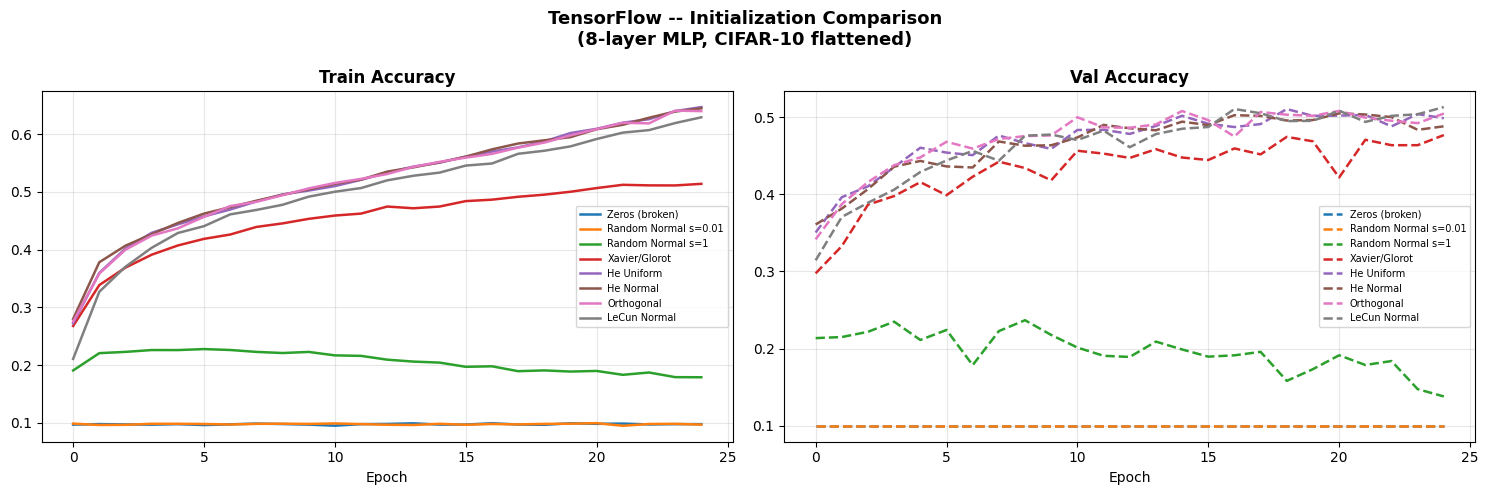


TF Final val accuracies
  Zeros (broken)             best=0.1000
  Random Normal s=0.01       best=0.1000
  Random Normal s=1          best=0.2368
  Xavier/Glorot              best=0.4767
  He Uniform                 best=0.5104
  He Normal                  best=0.5049
  Orthogonal                 best=0.5080
  LeCun Normal               best=0.5130


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
colors = plt.cm.tab10.colors
for i, (label, h) in enumerate(histories_tf.items()):
    c = colors[i % 10]
    axes[0].plot(h.history['accuracy'],     color=c, label=label, lw=1.8)
    axes[1].plot(h.history['val_accuracy'], color=c, label=label, lw=1.8, ls='--')
for ax, title in zip(axes, ['Train Accuracy', 'Val Accuracy']):
    ax.set_title(title, fontweight='bold'); ax.set_xlabel('Epoch')
    ax.legend(fontsize=7); ax.grid(alpha=.3)
plt.suptitle('TensorFlow -- Initialization Comparison\n(8-layer MLP, CIFAR-10 flattened)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print('\nTF Final val accuracies')
for label, h in histories_tf.items():
    print(f'  {label:25s}  best={max(h.history["val_accuracy"]):.4f}')

---
## 2 — Gradient flow at epoch 0
A bad init causes immediate vanishing or exploding gradients.

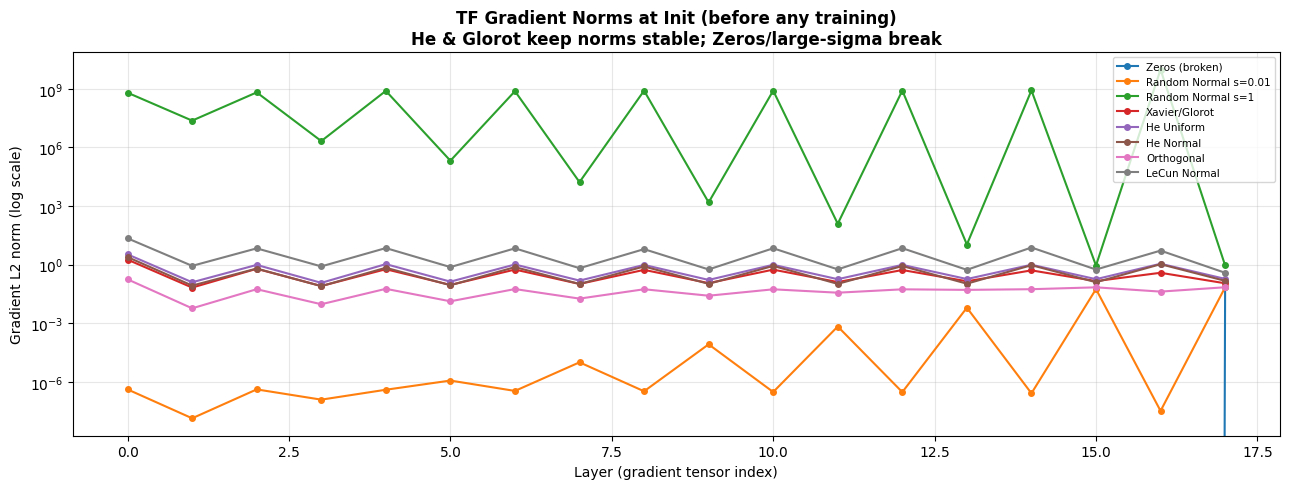

In [6]:
def grad_norm_tf(init, act, x_batch, y_batch):
    tf.random.set_seed(0)
    model = build_mlp_tf(init, act)
    x_t = tf.constant(x_batch)
    y_t = tf.constant(y_batch)
    with tf.GradientTape() as tape:
        pred = model(x_t, training=True)
        loss = tf.reduce_mean(
            tf.keras.losses.sparse_categorical_crossentropy(y_t, pred))
    grads = tape.gradient(loss, model.trainable_variables)
    return np.array([tf.norm(g).numpy() for g in grads if g is not None])

x_b, y_b = x_tr[:BATCH], y_tr[:BATCH]

fig, ax = plt.subplots(figsize=(13, 5))
for i, (label, init, act, _) in enumerate(CONFIGS_TF):
    norms = grad_norm_tf(init, act, x_b, y_b)
    ax.plot(norms, 'o-', label=label, lw=1.5, markersize=4, color=colors[i % 10])
ax.set_xlabel('Layer (gradient tensor index)')
ax.set_ylabel('Gradient L2 norm (log scale)')
ax.set_yscale('log')
ax.set_title('TF Gradient Norms at Init (before any training)\n'
             'He & Glorot keep norms stable; Zeros/large-sigma break',
             fontweight='bold')
ax.legend(fontsize=7.5); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

---
## 3 — PyTorch Initializations

In [7]:
from torchvision import datasets, transforms

tfm = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    transforms.Lambda(lambda x: x.view(-1))  # flatten to (3072,)
])
root = '/tmp/cifar'
train_set = datasets.CIFAR10(root, train=True,  download=True,  transform=tfm)
test_set  = datasets.CIFAR10(root, train=False, download=False, transform=tfm)
loader_tr = DataLoader(train_set, BATCH, shuffle=True,  num_workers=2, pin_memory=True)
loader_te = DataLoader(test_set,  BATCH, shuffle=False, num_workers=2, pin_memory=True)
print('PT data ready')

100%|██████████| 170M/170M [00:03<00:00, 48.8MB/s]


PT data ready


In [9]:
def make_mlp_pt(init_fn, act_cls):
    """DEPTH-layer MLP; init_fn applied to every Linear.weight."""
    lyrs = []
    in_d = 3072
    for _ in range(DEPTH):
        fc = nn.Linear(in_d, 256)
        init_fn(fc.weight)
        nn.init.zeros_(fc.bias)
        lyrs += [fc, act_cls()]
        in_d = 256
    fc_out = nn.Linear(256, 10)
    nn.init.xavier_uniform_(fc_out.weight)
    lyrs.append(fc_out)
    return nn.Sequential(*lyrs).to(DEVICE)


# (label, init_fn, act_cls, description)
CONFIGS_PT = [
    ('Zeros (broken)',
     lambda w: nn.init.zeros_(w), nn.ReLU,
     'All weights=0 -> dead network'),
    ('Rand Normal s=0.01',
     lambda w: nn.init.normal_(w, std=0.01), nn.ReLU,
     'Tiny random -> vanishes in deep net'),
    ('Rand Normal s=1.0',
     lambda w: nn.init.normal_(w, std=1.0),  nn.ReLU,
     'Large random -> exploding activations'),
    ('Xavier Uniform',
     lambda w: nn.init.xavier_uniform_(w),   nn.Tanh,
     'For tanh/sigmoid: var = 2/(fan_in+fan_out)'),
    ('He Uniform',
     lambda w: nn.init.kaiming_uniform_(w, nonlinearity='relu'), nn.ReLU,
     'For ReLU: var = 2/fan_in'),
    ('He Normal',
     lambda w: nn.init.kaiming_normal_(w,  nonlinearity='relu'), nn.ReLU,
     'He with normal dist'),
    ('Orthogonal',
     lambda w: nn.init.orthogonal_(w), nn.ReLU,
     'Orthonormal rows -> stable gradients in very deep nets'),
    ('Sparse (0.9)',
     lambda w: nn.init.sparse_(w, sparsity=0.9, std=0.01), nn.ReLU,
     '90% zeros at init -> implicit L0 regularization'),
]


def run_pt(label, init_fn, act_cls):
    torch.manual_seed(42)
    model = make_mlp_pt(init_fn, act_cls)
    opt   = torch.optim.Adam(model.parameters())
    crit  = nn.CrossEntropyLoss()
    tr_a, va_a = [], []
    for ep in range(1, EPOCHS + 1):
        model.train(); c, n = 0, 0
        for x, y in loader_tr:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            out  = model(x)
            loss = crit(out, y)
            loss.backward(); opt.step()
            c += (out.argmax(1) == y).sum().item(); n += y.size(0)
        tr_a.append(c / n)
        model.eval(); c2, n2 = 0, 0
        with torch.no_grad():
            for x, y in loader_te:
                x, y = x.to(DEVICE), y.to(DEVICE)
                c2 += (model(x).argmax(1) == y).sum().item(); n2 += y.size(0)
        va_a.append(c2 / n2)
        if ep % 10 == 0: print(f'  [{label}] ep {ep}  val={va_a[-1]:.4f}')
    return tr_a, va_a

results_pt = {}
for label, init_fn, act_cls, desc in CONFIGS_PT:
    print(f'\n-> {label}: {desc}')
    results_pt[label] = run_pt(label, init_fn, act_cls)
    print(f'  best val = {max(results_pt[label][1]):.4f}')


-> Zeros (broken): All weights=0 -> dead network
  [Zeros (broken)] ep 10  val=0.1000
  [Zeros (broken)] ep 20  val=0.1000
  best val = 0.1000

-> Rand Normal s=0.01: Tiny random -> vanishes in deep net
  [Rand Normal s=0.01] ep 10  val=0.5159
  [Rand Normal s=0.01] ep 20  val=0.5165
  best val = 0.5338

-> Rand Normal s=1.0: Large random -> exploding activations
  [Rand Normal s=1.0] ep 10  val=0.1949
  [Rand Normal s=1.0] ep 20  val=0.1737
  best val = 0.2005

-> Xavier Uniform: For tanh/sigmoid: var = 2/(fan_in+fan_out)
  [Xavier Uniform] ep 10  val=0.4799
  [Xavier Uniform] ep 20  val=0.4847
  best val = 0.4847

-> He Uniform: For ReLU: var = 2/fan_in
  [He Uniform] ep 10  val=0.5205
  [He Uniform] ep 20  val=0.5194
  best val = 0.5276

-> He Normal: He with normal dist
  [He Normal] ep 10  val=0.5243
  [He Normal] ep 20  val=0.5115
  best val = 0.5272

-> Orthogonal: Orthonormal rows -> stable gradients in very deep nets
  [Orthogonal] ep 10  val=0.5292
  [Orthogonal] ep 20  val=

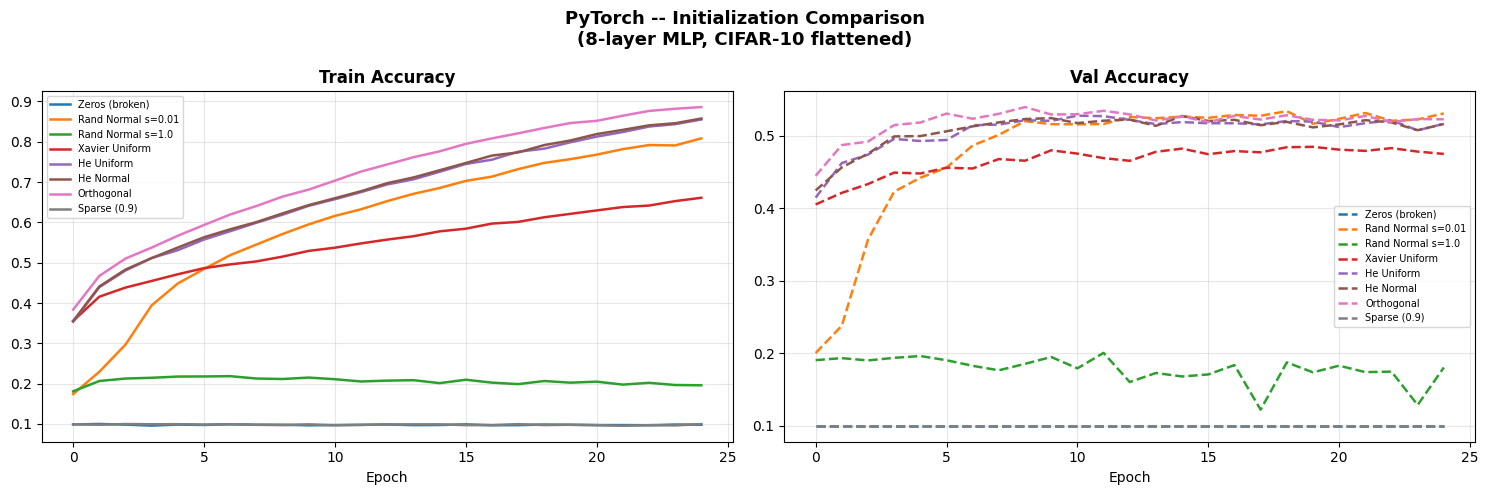


PT Final val accuracies
  Zeros (broken)             best=0.1000
  Rand Normal s=0.01         best=0.5338
  Rand Normal s=1.0          best=0.2005
  Xavier Uniform             best=0.4847
  He Uniform                 best=0.5276
  He Normal                  best=0.5272
  Orthogonal                 best=0.5395
  Sparse (0.9)               best=0.1000


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
colors = plt.cm.tab10.colors
for i, (label, (tr, va)) in enumerate(results_pt.items()):
    c = colors[i % 10]
    axes[0].plot(tr, color=c, label=label, lw=1.8)
    axes[1].plot(va, color=c, label=label, lw=1.8, ls='--')
for ax, title in zip(axes, ['Train Accuracy', 'Val Accuracy']):
    ax.set_title(title, fontweight='bold'); ax.set_xlabel('Epoch')
    ax.legend(fontsize=7); ax.grid(alpha=.3)
plt.suptitle('PyTorch -- Initialization Comparison\n(8-layer MLP, CIFAR-10 flattened)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print('\nPT Final val accuracies')
for label, (_, va) in results_pt.items():
    print(f'  {label:25s}  best={max(va):.4f}')

---
## 4 — Gradient norms at init (PyTorch)

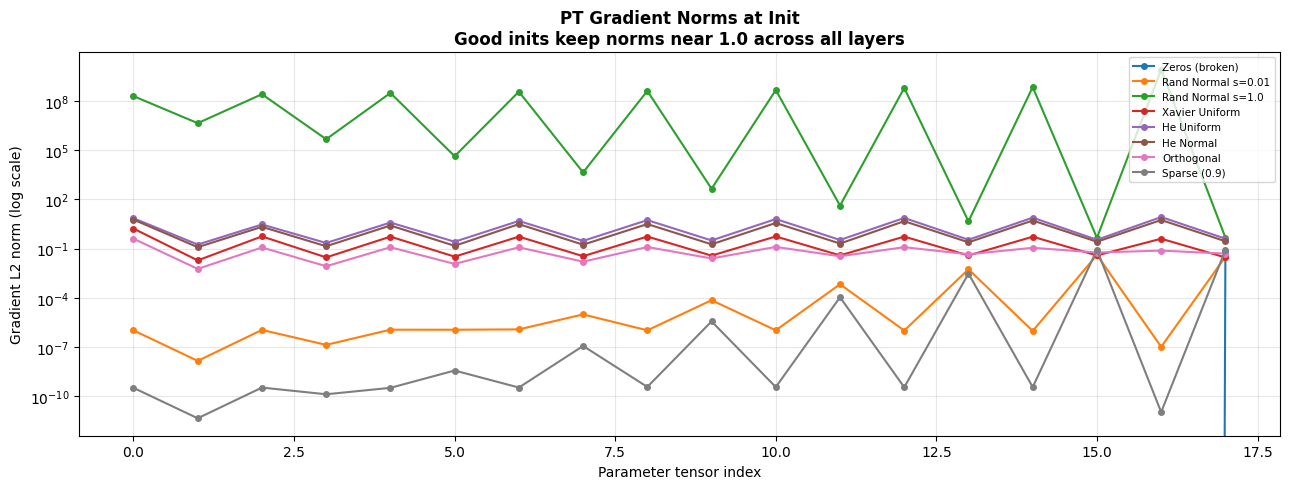

In [11]:
def grad_norms_pt(init_fn, act_cls):
    torch.manual_seed(0)
    model = make_mlp_pt(init_fn, act_cls)
    model.train()
    x_b, y_b = next(iter(loader_tr))
    x_b, y_b = x_b.to(DEVICE), y_b.to(DEVICE)
    loss = nn.CrossEntropyLoss()(model(x_b), y_b)
    loss.backward()
    return np.array([p.grad.norm().item()
                     for p in model.parameters() if p.grad is not None])

fig, ax = plt.subplots(figsize=(13, 5))
for i, (label, init_fn, act_cls, _) in enumerate(CONFIGS_PT):
    norms = grad_norms_pt(init_fn, act_cls)
    ax.plot(norms, 'o-', label=label, lw=1.5, markersize=4, color=colors[i % 10])
ax.set_xlabel('Parameter tensor index')
ax.set_ylabel('Gradient L2 norm (log scale)')
ax.set_yscale('log')
ax.set_title('PT Gradient Norms at Init\nGood inits keep norms near 1.0 across all layers',
             fontweight='bold')
ax.legend(fontsize=7.5); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

---
## 5 — Activation statistics at init
Dead ReLUs and saturated neurons are visible immediately.

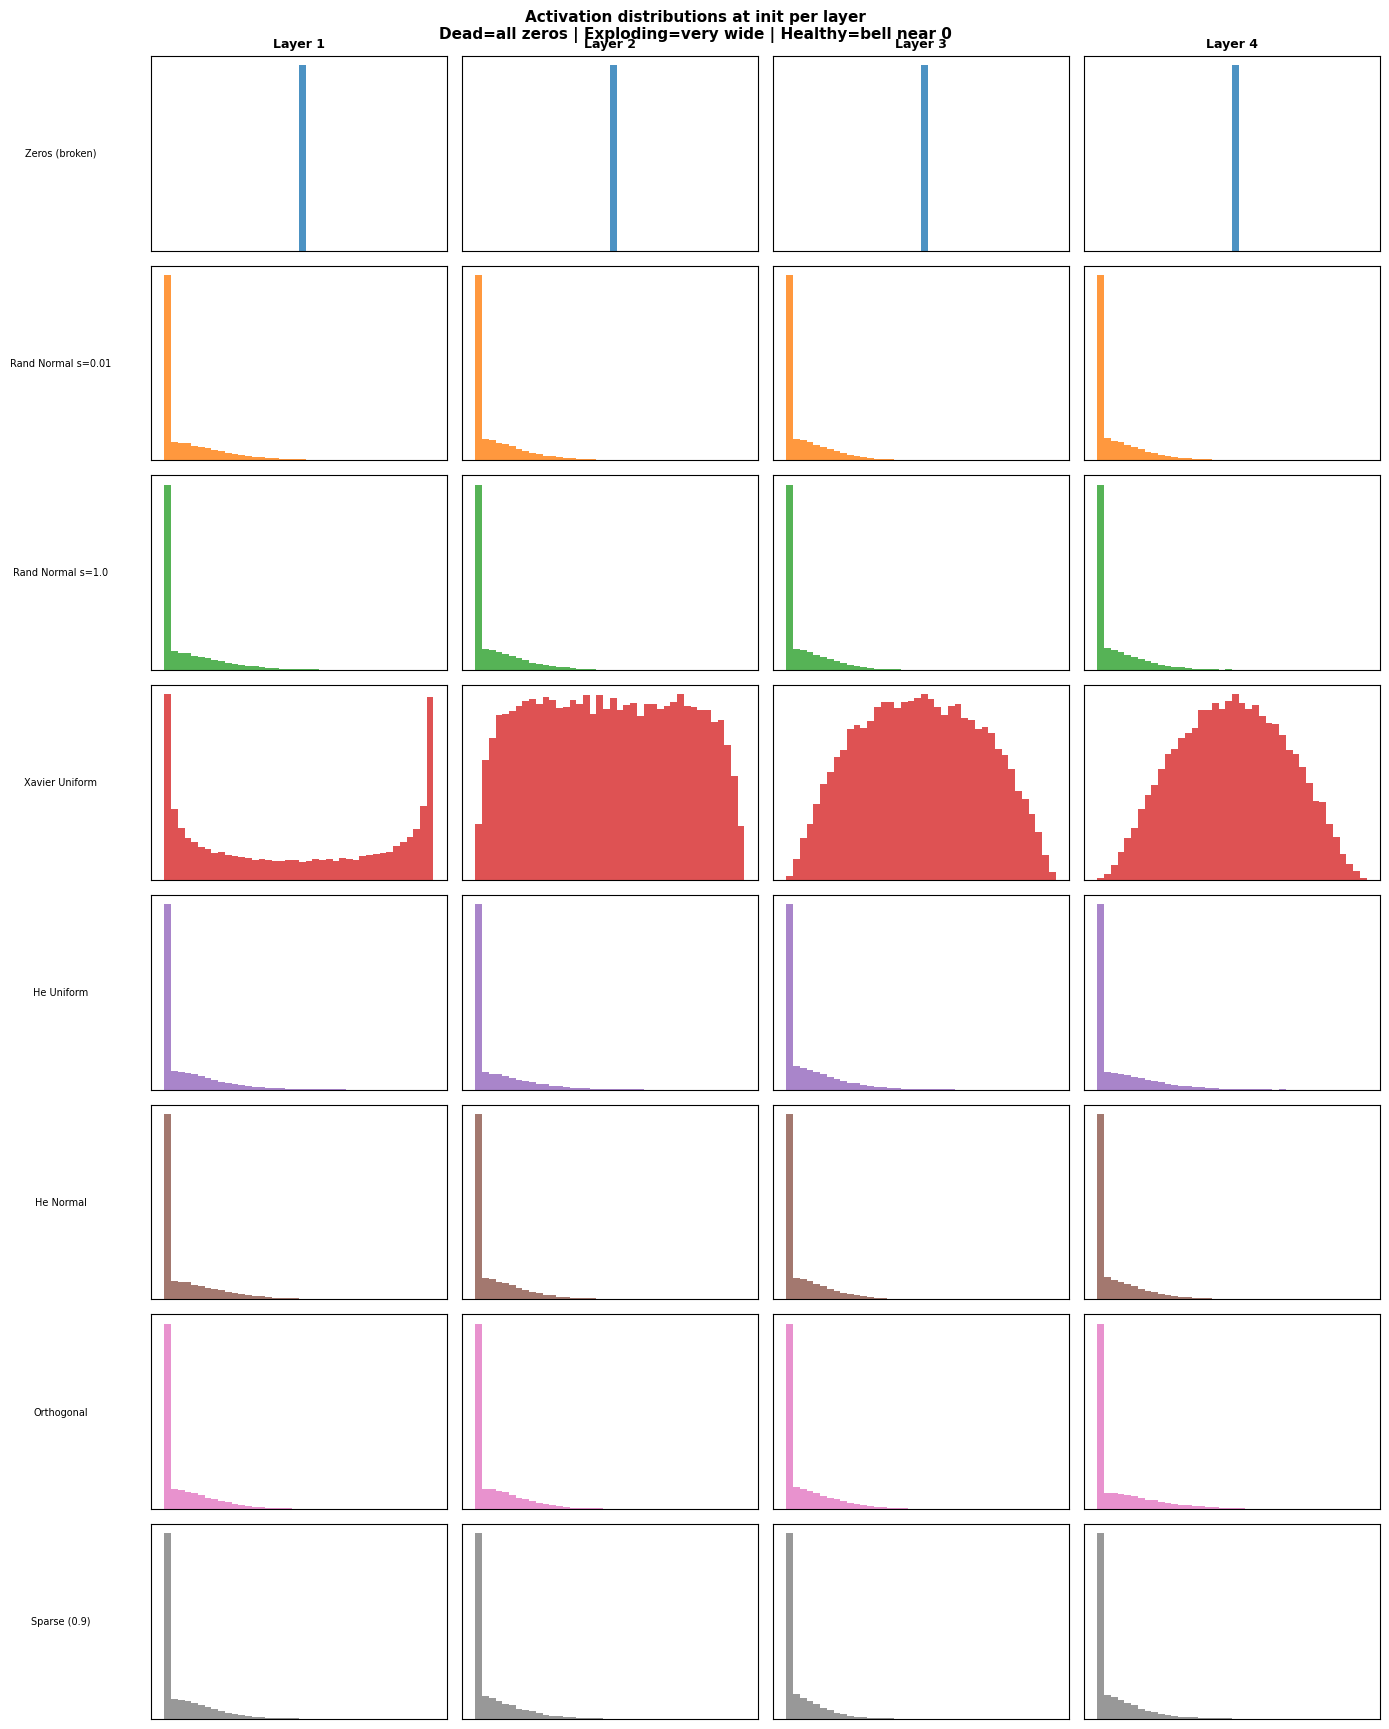

In [12]:
def capture_activations(init_fn, act_cls, n_layers=4):
    torch.manual_seed(0)
    model = make_mlp_pt(init_fn, act_cls)
    model.eval()
    acts, hooks = [], []
    for m in model.modules():
        if isinstance(m, (nn.ReLU, nn.Tanh, nn.SELU)):
            hooks.append(m.register_forward_hook(
                lambda mod, inp, out, a=acts:
                    a.append(out.detach().cpu().numpy().flatten())))
    x_b = next(iter(loader_te))[0][:128].to(DEVICE)
    with torch.no_grad(): model(x_b)
    for h in hooks: h.remove()
    return acts[:n_layers]

fig, axes = plt.subplots(len(CONFIGS_PT), 4,
                         figsize=(14, 2.2 * len(CONFIGS_PT)))
for row, (label, init_fn, act_cls, _) in enumerate(CONFIGS_PT):
    acts = capture_activations(init_fn, act_cls, n_layers=4)
    for col in range(4):
        ax = axes[row, col]
        if col < len(acts) and len(acts[col]) > 0:
            ax.hist(acts[col], bins=40, color=colors[row % 10],
                    alpha=0.8, density=True)
        ax.set_xticks([]); ax.set_yticks([])
        if col == 0:
            ax.set_ylabel(label, fontsize=7, rotation=0,
                          labelpad=65, va='center')
        if row == 0:
            ax.set_title(f'Layer {col+1}', fontsize=9, fontweight='bold')
plt.suptitle('Activation distributions at init per layer\n'
             'Dead=all zeros | Exploding=very wide | Healthy=bell near 0',
             fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

---
## 6 — A/B bar chart: best val accuracy per init

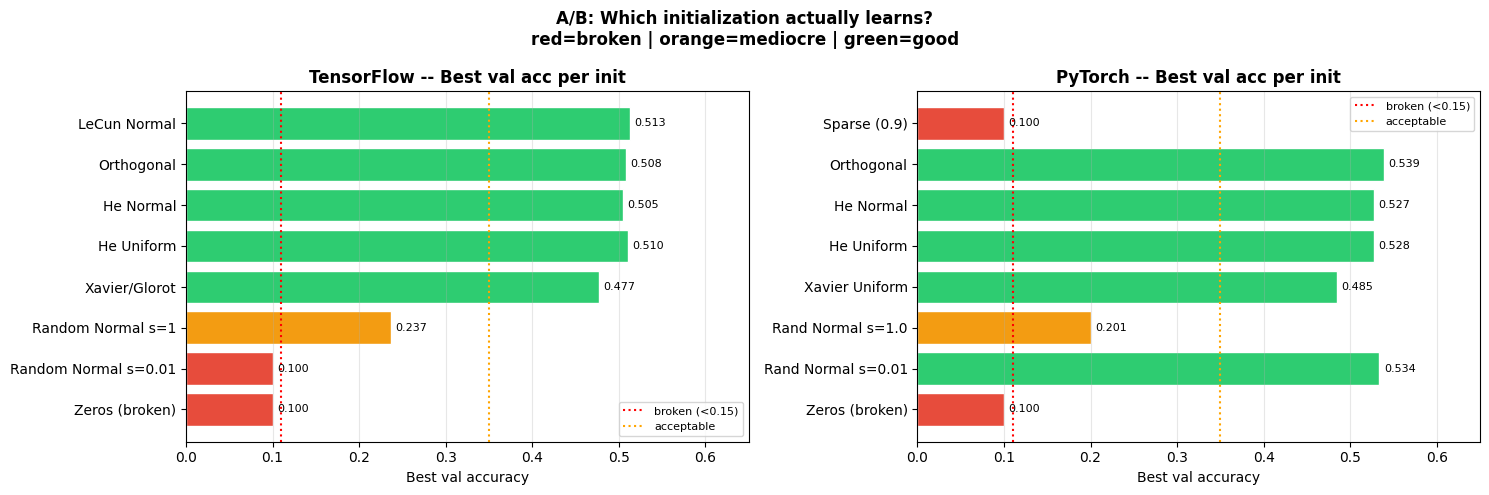

In [13]:
labels_pt = list(results_pt.keys())
bests_pt  = [max(va) for _, va in results_pt.values()]
labels_tf = list(histories_tf.keys())
bests_tf  = [max(h.history['val_accuracy']) for h in histories_tf.values()]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, labels, bests, fw in zip(
        axes,
        [labels_tf, labels_pt],
        [bests_tf,  bests_pt],
        ['TensorFlow', 'PyTorch']):
    bar_colors = ['#e74c3c' if b < 0.15 else
                  '#f39c12' if b < 0.35 else '#2ecc71' for b in bests]
    bars = ax.barh(labels, bests, color=bar_colors, edgecolor='white')
    ax.set_xlim(0, 0.65)
    ax.set_xlabel('Best val accuracy')
    ax.set_title(f'{fw} -- Best val acc per init', fontweight='bold')
    for bar, val in zip(bars, bests):
        ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', va='center', fontsize=8)
    ax.axvline(0.11, color='red',    ls=':', lw=1.5, label='broken (<0.15)')
    ax.axvline(0.35, color='orange', ls=':', lw=1.5, label='acceptable')
    ax.legend(fontsize=8); ax.grid(axis='x', alpha=.3)

plt.suptitle('A/B: Which initialization actually learns?\n'
             'red=broken | orange=mediocre | green=good',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

---
## 7 — Quick-reference table: when to use what

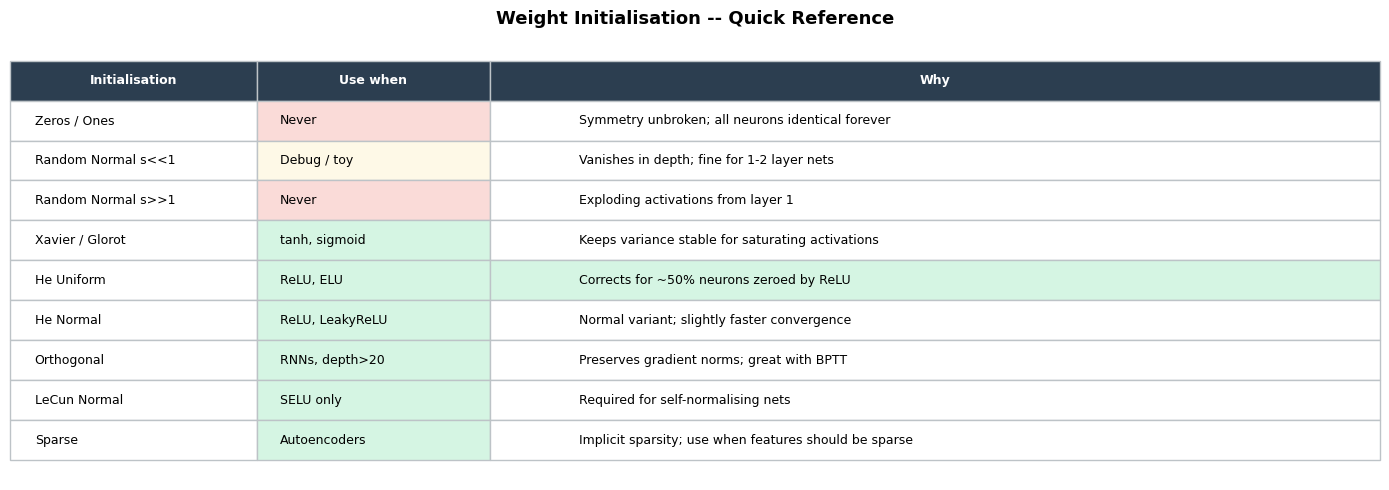

In [14]:
summary = [
    ('Zeros / Ones',       'Never',          'Symmetry unbroken; all neurons identical forever'),
    ('Random Normal s<<1', 'Debug / toy',    'Vanishes in depth; fine for 1-2 layer nets'),
    ('Random Normal s>>1', 'Never',          'Exploding activations from layer 1'),
    ('Xavier / Glorot',    'tanh, sigmoid',  'Keeps variance stable for saturating activations'),
    ('He Uniform',         'ReLU, ELU',      'Corrects for ~50% neurons zeroed by ReLU'),
    ('He Normal',          'ReLU, LeakyReLU','Normal variant; slightly faster convergence'),
    ('Orthogonal',         'RNNs, depth>20', 'Preserves gradient norms; great with BPTT'),
    ('LeCun Normal',       'SELU only',      'Required for self-normalising nets'),
    ('Sparse',             'Autoencoders',   'Implicit sparsity; use when features should be sparse'),
]

fig, ax = plt.subplots(figsize=(14, 5))
ax.axis('off')
table = ax.table(
    cellText=summary,
    colLabels=['Initialisation', 'Use when', 'Why'],
    cellLoc='left', loc='center',
    colWidths=[0.18, 0.17, 0.65]
)
table.auto_set_font_size(False); table.set_fontsize(9); table.scale(1, 2.1)
for (r, c), cell in table.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    elif 'Never' in str(cell.get_text().get_text()):
        cell.set_facecolor('#fadbd8')
    elif any(k in str(cell.get_text().get_text())
             for k in ['ReLU','tanh','SELU','RNN','Auto']):
        cell.set_facecolor('#d5f5e3')
    elif 'Debug' in str(cell.get_text().get_text()):
        cell.set_facecolor('#fef9e7')
    cell.set_edgecolor('#bdc3c7')
plt.title('Weight Initialisation -- Quick Reference',
          fontsize=13, fontweight='bold', pad=12)
plt.tight_layout(); plt.show()